In [38]:
!pip install scikit-fuzzy

In [39]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from skimage.color import rgb2lab
from skimage.feature import canny
from skimage.metrics import structural_similarity as ssim

import skfuzzy as fuzz

In [40]:
DATASET_PATH = "/kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TRAIN"
IMG_SIZE = 128
N_IMAGES = 200

In [41]:
all_images = []

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    for img in os.listdir(folder_path):
        all_images.append(os.path.join(folder_path, img))

print("Total images found:", len(all_images))

# Random subset
image_paths = random.sample(all_images, N_IMAGES)
print("Using subset:", len(image_paths))

Total images found: 9957
Using subset: 200


In [42]:
def load_images(paths):
    images_rgb = []
    images_features = []
    
    for path in paths:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        # LAB
        lab = rgb2lab(img)
        
        # HSV
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        
        # Combine features → 5 channels
        features = np.dstack((lab, hsv[:,:,0], hsv[:,:,1]))
        
        images_rgb.append(img)
        images_features.append(features)
        
    return np.array(images_rgb), np.array(images_features)

images_rgb, images_lab = load_images(image_paths)

In [43]:
def show_results(original, kmeans_mask, fcm_mask):
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original)
    plt.axis("off")
    
    plt.subplot(1,3,2)
    plt.title("KMeans")
    plt.imshow(kmeans_mask, cmap='gray')
    plt.axis("off")
    
    plt.subplot(1,3,3)
    plt.title("FCM")
    plt.imshow(fcm_mask, cmap='gray')
    plt.axis("off")
    
    plt.show()

In [44]:
def kmeans_segmentation(feature_img, k=3):
    pixels = feature_img.reshape((-1,5))
    
    kmeans = KMeans(n_clusters=k, n_init=10)
    labels = kmeans.fit_predict(pixels)
    centers = kmeans.cluster_centers_
    
    segmented = labels.reshape(IMG_SIZE, IMG_SIZE)
    
    # L, a, b, H, S
    L = centers[:,0]
    A = centers[:,1]
    S = centers[:,4]
    
    # nucleus score
    scores = (A * 0.6) + (S * 0.4) - (L * 0.3)
    nucleus_cluster = np.argmax(scores)
    
    mask = (segmented == nucleus_cluster).astype(np.uint8)
    return mask

In [45]:
def fcm_segmentation(feature_img, k=3):
    pixels = feature_img.reshape((-1,5)).T
    
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        pixels, c=k, m=2, error=0.005, maxiter=1000
    )
    
    labels = np.argmax(u, axis=0)
    segmented = labels.reshape(IMG_SIZE, IMG_SIZE)
    
    L = cntr[:,0]
    A = cntr[:,1]
    S = cntr[:,4]
    
    scores = (A * 0.6) + (S * 0.4) - (L * 0.3)
    nucleus_cluster = np.argmax(scores)
    
    mask = (segmented == nucleus_cluster).astype(np.uint8)
    return mask

In [46]:
from skimage.metrics import structural_similarity as ssim

def boundary_similarity(mask1, mask2):
    edge1 = canny(mask1).astype(float)
    edge2 = canny(mask2).astype(float)
    
    return ssim(edge1, edge2, data_range=1.0)

In [47]:
kmeans_masks = []
fcm_masks = []
scores = []

for i, lab in enumerate(images_lab):
    
    k_mask = kmeans_segmentation(lab)
    f_mask = fcm_segmentation(lab)
    
    score = boundary_similarity(k_mask, f_mask)
    
    kmeans_masks.append(k_mask)
    fcm_masks.append(f_mask)
    scores.append(score)
    
    if i % 20 == 0:
        print(f"Processed {i}/{N_IMAGES}")

print("Processing finished!")

Processed 0/200
Processed 20/200
Processed 40/200
Processed 60/200
Processed 80/200
Processed 100/200
Processed 120/200
Processed 140/200
Processed 160/200
Processed 180/200
Processing finished!


In [48]:
print("Average Boundary Similarity (SSIM):", np.mean(scores))

Average Boundary Similarity (SSIM): 1.0


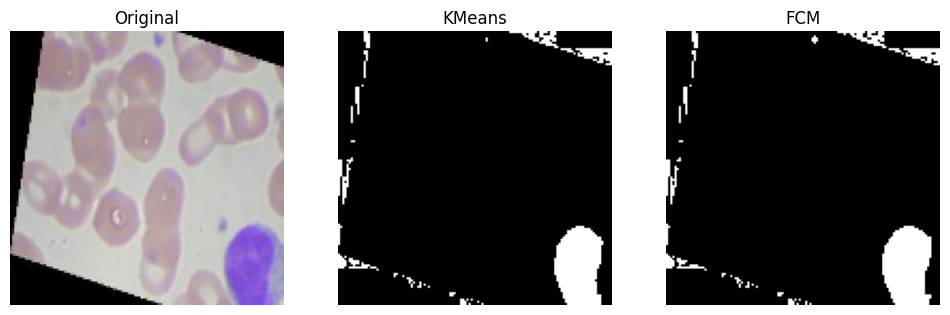

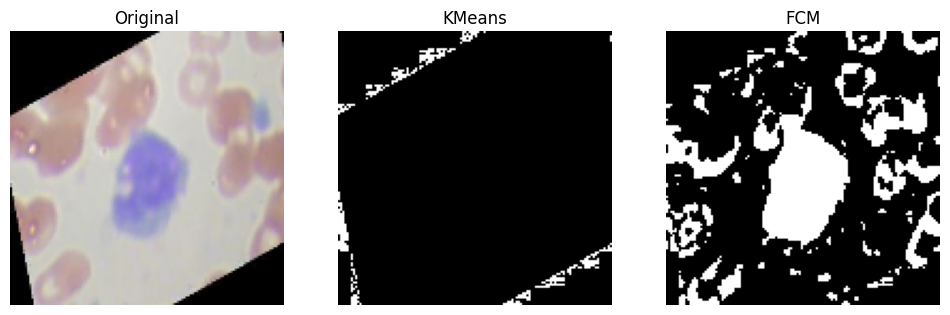

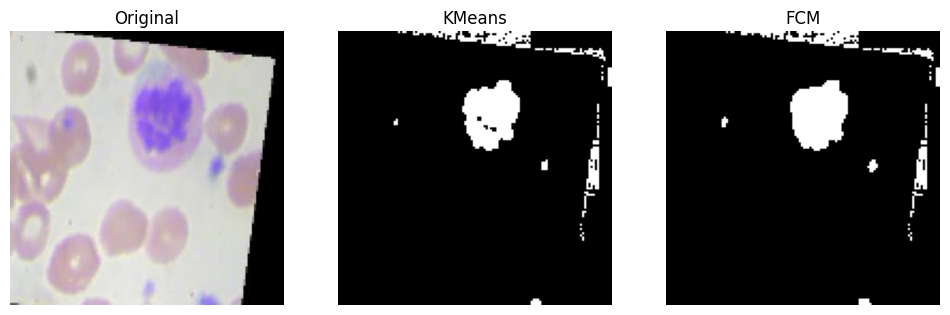

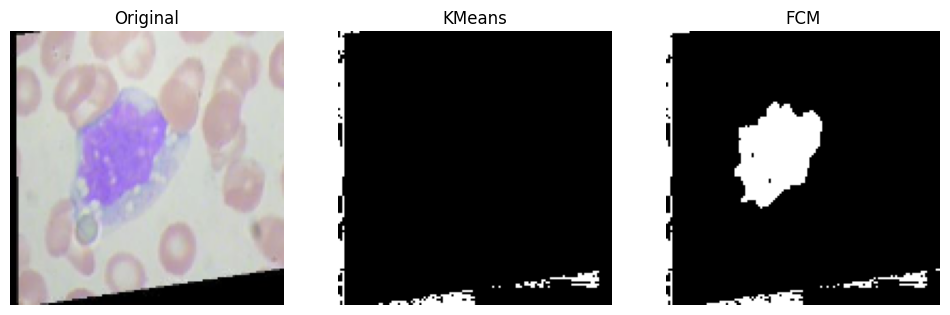

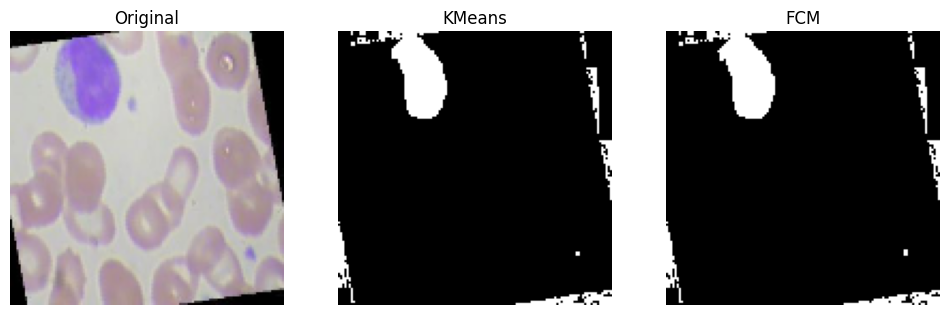

In [49]:
for i in range(5):
    idx = random.randint(0, N_IMAGES-1)
    show_results(images_rgb[idx], kmeans_masks[idx], fcm_masks[idx])



This experiment highlighted the practical differences between the two clustering paradigms:

- **Hard Clustering (K-Means)**  
  Each pixel belongs to only one cluster (strict segmentation)

- **Soft Clustering (FCM)**  
  Pixels can partially belong to multiple clusters.

## Final Conclusion

Overall, **Fuzzy C-Means proved more suitable for medical image segmentation** because biological structures rarely have sharp boundaries.  
Despite minor noise artifacts, FCM produced more realistic and medically meaningful nucleus segmentation compared to K-Means.

This experiment demonstrates why **soft clustering methods are often preferred in biomedical image analysis**.